Dataset Shape: (2200, 8)

First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Missing values in columns:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total Unique Crops: 22


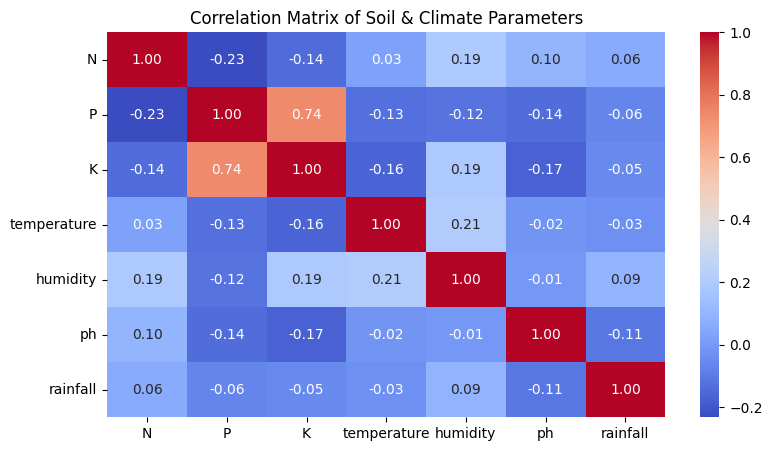

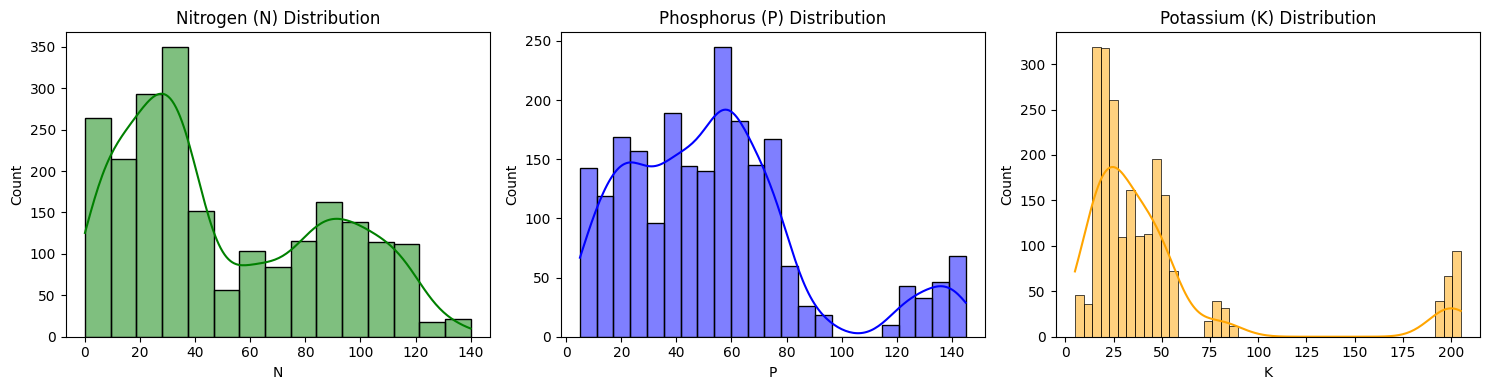


Training Samples Count: 1760
Testing Samples Count: 440

--------------------------------------------------
Decision Tree Accuracy: 98.64%
Random Forest Accuracy: 99.32%
--------------------------------------------------

Classification Report (Random Forest):

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00 

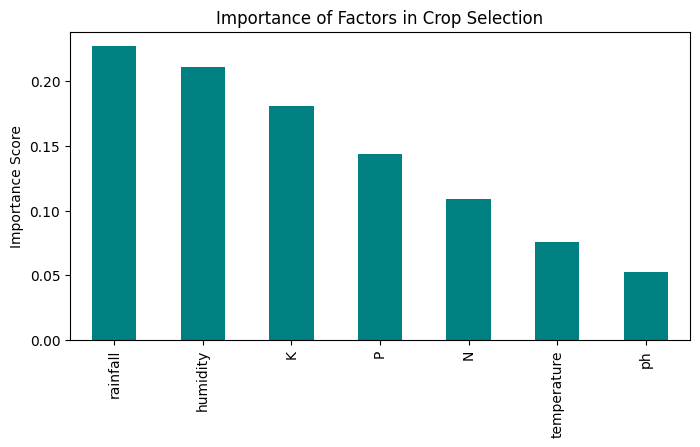

--------------------------------------------------
Recommended Crop for the given soil: RICE
--------------------------------------------------


In [9]:
# ==========================================
# 1. LIBRARIES IMPORT & DATASET LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load CSV dataset
df = pd.read_csv('Crop_recommendation.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# ==========================================
# 2. DATA EXPLORATION & CHECKS
# ==========================================
print("\nMissing values in columns:")
print(df.isnull().sum())
print("\nTotal Unique Crops:", df['label'].nunique())

# ==========================================
# 3. DATA VISUALIZATION (EDA)
# ==========================================
# Heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Soil & Climate Parameters")
plt.savefig("correlation_heatmap.png", bbox_inches='tight')
plt.show()

# Nutrient Distribution
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['N'], kde=True, color='green')
plt.title('Nitrogen (N) Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['P'], kde=True, color='blue')
plt.title('Phosphorus (P) Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['K'], kde=True, color='orange')
plt.title('Potassium (K) Distribution')
plt.tight_layout()
plt.savefig("nutrient_distribution.png", bbox_inches='tight')
plt.show()

# ==========================================
# 4. TRAIN-TEST SPLIT
# ==========================================
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTraining Samples Count:", X_train.shape[0])
print("Testing Samples Count:", X_test.shape[0])

# ==========================================
# 5. MODEL TRAINING & COMPARISON
# ==========================================
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("\n--------------------------------------------------")
print(f"Decision Tree Accuracy: {dt_acc * 100:.2f}%")
print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")
print("--------------------------------------------------")
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, rf_pred))

# ==========================================
# 6. FEATURE IMPORTANCE & FARMER TESTING
# ==========================================
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
feature_imp.plot(kind='bar', color='teal')
plt.title("Importance of Factors in Crop Selection")
plt.ylabel("Importance Score")
plt.savefig("feature_importance.png", bbox_inches='tight')
plt.show()

# Sample Input Test (Farmer Testing)
sample_test = pd.DataFrame([[90, 42, 43, 20.87, 82.00, 6.50, 202.93]], columns=X.columns)
result = rf_model.predict(sample_test)
print("--------------------------------------------------")
print(f"Recommended Crop for the given soil: {result[0].upper()}")
print("--------------------------------------------------")